<a href="https://colab.research.google.com/github/Priscilla-/SCiML_test_code/blob/main/DMD_Koopman_SINDy_toy_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMD, Koopman (EDMD) and SINDy on a single toy problem

**Companion notebook to the lecture *Data-Driven Discovery of Dynamical Systems*.**  
Designed for Google Colab — no local installation required.

---

## What this notebook does

We apply three data-driven methods, *one after the other*, to the **same** simple
two-dimensional nonlinear ODE, and then compare them head-to-head.

1. **Dynamic Mode Decomposition (DMD)** — best-fit *linear* operator on snapshots.
2. **Extended DMD / Koopman (EDMD)** — DMD applied in a richer dictionary of
   nonlinear observables.  We pick a polynomial dictionary that is rich enough
   to *exactly* close the dynamics, so we recover the analytic Koopman
   eigenfunctions.
3. **Sparse Identification of Nonlinear Dynamics (SINDy)** — sparse regression
   that recovers the *symbolic* governing ODE.

We then compare the three methods on:

- forward-prediction error against the true trajectory,
- the recovered spectrum (eigenvalues / growth rates),
- interpretability (do we recover something we can *read* as physics?).

## Why this particular toy problem?

The system
$$\dot x_1 = \mu\, x_1, \qquad \dot x_2 = \lambda\,(x_2 - x_1^{2}), \qquad \mu < \lambda < 0,$$
appears in Brunton, Brunton, Proctor & Kutz (2016) and Lusch, Kutz & Brunton (2018).
It is the smallest nontrivial system that simultaneously illustrates the strengths and
weaknesses of all three methods:

- Plain **DMD** fits a linear model in $(x_1, x_2)$ — it can capture the linear
  $x_1$-direction but is *forced to approximate* the cross-coupling through the
  nonlinear term $x_1^{2}$. The result is a biased linear surrogate.
- **Koopman/EDMD** lifts the state to $(1, x_1, x_2, x_1^{2})$. In this 4-D
  observable space the dynamics are *exactly linear*; we can therefore read off
  the Koopman eigenfunctions in closed form and compare to the analytic answer.
- **SINDy** with a polynomial library of degree 2 returns
  $\dot x_1 = \mu\, x_1$ and $\dot x_2 = \lambda\, x_2 - \lambda\, x_1^{2}$
  with the correct coefficients — the equations themselves.

## References

- P. J. Schmid, *Dynamic mode decomposition of numerical and experimental data*,
  J. Fluid Mech. **656**, 5–28 (2010).
- J. H. Tu, C. W. Rowley, D. M. Luchtenburg, S. L. Brunton, J. N. Kutz,
  *On dynamic mode decomposition: theory and applications*,
  J. Comput. Dyn. **1**(2), 391–421 (2014).
- M. O. Williams, I. G. Kevrekidis, C. W. Rowley,
  *A data-driven approximation of the Koopman operator: extending dynamic mode
  decomposition*, J. Nonlinear Sci. **25**, 1307–1346 (2015).
- S. L. Brunton, J. L. Proctor, J. N. Kutz,
  *Discovering governing equations from data by sparse identification of
  nonlinear dynamical systems*, PNAS **113**(15), 3932–3937 (2016).
- B. Lusch, J. N. Kutz, S. L. Brunton,
  *Deep learning for universal linear embeddings of nonlinear dynamics*,
  Nat. Commun. **9**, 4950 (2018).
- S. L. Brunton & J. N. Kutz,
  *Data-Driven Science and Engineering*, 2nd ed., CUP (2022) — Ch. 7.

---
## 1. Setup and conventions

We rely only on the standard scientific-Python stack. Colab has these
pre-installed.  Two stylistic choices kept throughout the notebook:

- **Snapshot matrices are stored column-wise** ($n \times m$).  This matches
  the original DMD literature (Schmid 2010, Tu et al. 2014).  Whenever we hand
  a matrix to a regression routine we transpose explicitly so the code reads
  the same way as the math.
- **Continuous-time eigenvalues** $\omega_j$ are reported throughout.  The
  discrete-time eigenvalues $\lambda_j$ are converted via
  $\omega_j = \ln(\lambda_j)/\Delta t$ when needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

np.random.seed(0)        # reproducibility
np.set_printoptions(precision=4, suppress=True)

# Larger default figure size and font for Colab
plt.rcParams.update({'figure.figsize': (8, 4.5),
                     'figure.dpi': 110,
                     'axes.grid': True,
                     'grid.alpha': 0.3,
                     'font.size': 11})

---
## 2. The toy problem

$$\dot x_1 = \mu\, x_1, \qquad \dot x_2 = \lambda\,(x_2 - x_1^{2}),\qquad \mu < \lambda < 0.$$

We choose $\mu = -0.05$ and $\lambda = -1.0$, so $x_1$ decays slowly and $x_2$
decays an order of magnitude faster but is *driven* by the nonlinear term
$x_1^{2}$.  The trajectory therefore curves towards the slow manifold
$x_2 = \frac{\lambda}{\lambda - 2\mu}\, x_1^{2}$ before sliding along it to
the origin.

### Analytic Koopman eigen-decomposition (we'll compare to this later)

With the lifted coordinates $\mathbf y = (x_1,\, x_2,\, x_1^{2})$ the dynamics
are linear with generator
$$\dot{\mathbf y} = \begin{pmatrix} \mu & 0 & 0 \\ 0 & \lambda & -\lambda \\ 0 & 0 & 2\mu \end{pmatrix} \mathbf y.$$
The exact Koopman eigenfunctions are
$$\varphi_1 = x_1,\quad \varphi_2 = x_2 - \tfrac{\lambda}{\lambda - 2\mu}\,x_1^{2},\quad \varphi_3 = x_1^{2},$$
with eigenvalues $\mu,\ \lambda,\ 2\mu$.  Keep these numbers handy — every
method below will try to reproduce them.

In [2]:
# --- Parameters of the toy ODE -------------------------------------
mu_true     = -0.05      # slow eigenvalue
lambda_true = -1.0       # fast eigenvalue

def rhs(t, x):
    """Right-hand side of the toy ODE \dot x = f(x)."""
    x1, x2 = x
    return [mu_true * x1,
            lambda_true * (x2 - x1**2)]

# --- Generate a clean trajectory -----------------------------------
x0 = np.array([1.5, -0.5])         # initial condition (off-manifold)
T  = 10.0                          # final time
dt = 0.05                          # snapshot spacing
t_eval = np.arange(0.0, T + dt, dt)

sol = solve_ivp(rhs, (0.0, T), x0, t_eval=t_eval,
                method='RK45', rtol=1e-9, atol=1e-12)
X_true = sol.y                     # shape (n=2, m+1)
print('X_true shape:', X_true.shape)

X_true shape: (2, 201)


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_13683/2544715136.py:6: SyntaxWarning: invalid escape sequence '\d'
  """Right-hand side of the toy ODE \dot x = f(x)."""


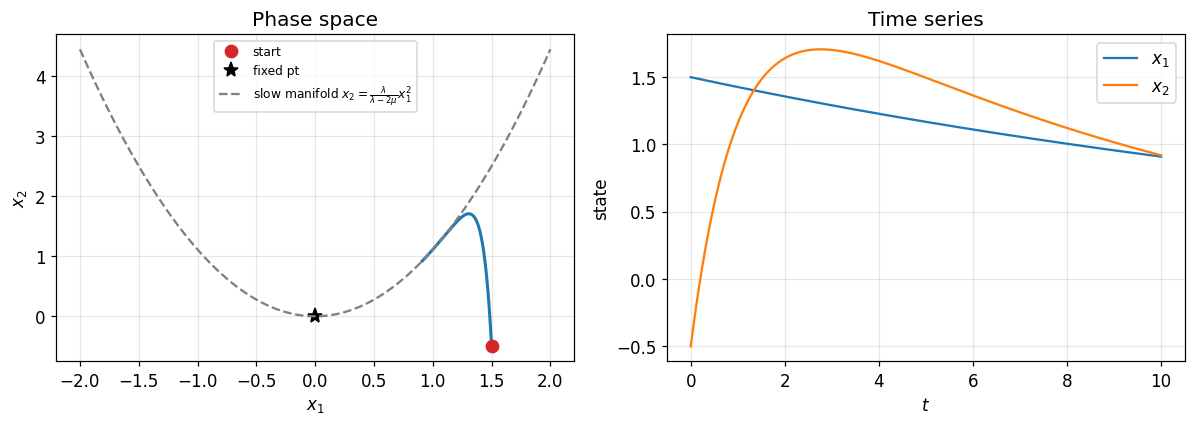

In [3]:
# --- Plot the trajectory in phase space and in time ----------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(X_true[0], X_true[1], lw=2)
ax[0].plot(*x0, 'o', ms=8, color='tab:red', label='start')
ax[0].plot(0, 0, 'k*', ms=10, label='fixed pt')
# The slow manifold: x_2 = lambda / (lambda - 2 mu) * x_1^2
x1_grid = np.linspace(-2, 2, 200)
ax[0].plot(x1_grid, lambda_true/(lambda_true - 2*mu_true) * x1_grid**2,
           '--', color='gray', label=r'slow manifold $x_2=\frac{\lambda}{\lambda-2\mu}x_1^2$')
ax[0].set_xlabel('$x_1$'); ax[0].set_ylabel('$x_2$')
ax[0].set_title('Phase space'); ax[0].legend(loc='best', fontsize=8)

ax[1].plot(t_eval, X_true[0], label='$x_1$')
ax[1].plot(t_eval, X_true[1], label='$x_2$')
ax[1].set_xlabel('$t$'); ax[1].set_ylabel('state'); ax[1].set_title('Time series')
ax[1].legend()

fig.tight_layout()
plt.show()

---
## 3. Dynamic Mode Decomposition (DMD)

**Idea.** Given snapshot pairs
$\mathbf X=[\mathbf x_0,\dots,\mathbf x_{m-1}]$ and
$\mathbf X'=[\mathbf x_1,\dots,\mathbf x_m]$, find the *best-fit linear*
operator $\mathbf A^{\star}$ such that
$$\mathbf X' \approx \mathbf A^{\star}\, \mathbf X.$$
The closed-form least-squares solution is
$\mathbf A^{\star} = \mathbf X'\, \mathbf X^{\dagger}$.
Computing $\mathbf A^{\star}$ explicitly is impractical when $n$ is large, so
the **Exact DMD** algorithm of Tu et al. (2014) works with the small *reduced*
operator
$\tilde{\mathbf A} = \mathbf U^{\!*}\, \mathbf X'\, \mathbf V\, \boldsymbol\Sigma^{-1}$,
where $\mathbf X = \mathbf U \boldsymbol\Sigma \mathbf V^{\!*}$ is the thin
SVD truncated to rank $r$.  Eigendecomposing $\tilde{\mathbf A}$ yields:

- **DMD eigenvalues** $\lambda_j$ (discrete time) →
  $\omega_j = \ln(\lambda_j)/\Delta t$ (continuous time);
- **DMD modes** $\boldsymbol\Phi = \mathbf X'\mathbf V \boldsymbol\Sigma^{-1} \mathbf W$
  where $\tilde{\mathbf A} \mathbf W = \mathbf W \boldsymbol\Lambda$;
- A **modal reconstruction**
  $\mathbf x(t) \approx \sum_j b_j \boldsymbol\phi_j e^{\omega_j t}$.

Below we implement the algorithm verbatim, then run it on the toy data.
Because $n=2$ and we expect the system to truly need *more than two* observables,
we already anticipate a mismatch — we record it carefully in §6.

In [4]:
def exact_dmd(X, Xp, dt, r=None):
    """
    Exact DMD (Tu et al. 2014).

    Parameters
    ----------
    X, Xp : (n, m) arrays
        Shifted snapshot pair, X' = A X.
    dt    : float
        Snapshot spacing.
    r     : int or None
        Truncation rank for the SVD. If None, full rank.

    Returns
    -------
    Phi    : (n, r) modes (columns).
    Lambda : (r,)   discrete-time eigenvalues.
    omega  : (r,)   continuous-time eigenvalues, omega = log(Lambda)/dt.
    b      : (r,)   amplitudes such that x_k ~ Phi diag(Lambda^k) b.
    """
    # 1. Thin SVD of X
    U, S, Vh = np.linalg.svd(X, full_matrices=False)
    if r is None:
        r = len(S)
    U_r  = U[:, :r]
    S_r  = S[:r]
    V_r  = Vh.conj().T[:, :r]
    Sinv = np.diag(1.0 / S_r)

    # 2. Project A onto the leading POD basis
    A_tilde = U_r.conj().T @ Xp @ V_r @ Sinv     # r x r

    # 3. Eigendecompose A_tilde
    Lambda, W = np.linalg.eig(A_tilde)

    # 4. Continuous-time eigenvalues
    omega = np.log(Lambda) / dt

    # 5. Exact DMD modes
    Phi = Xp @ V_r @ Sinv @ W                    # n x r

    # 6. Initial amplitudes from x_0 (here: first column of X)
    b = np.linalg.lstsq(Phi, X[:, 0], rcond=None)[0]
    return Phi, Lambda, omega, b

### Running DMD on the toy data

We assemble the snapshot pair from the trajectory, apply Exact DMD with full
rank ($r=2$ since $n=2$), and roll the resulting linear model forward to
compare with the truth.

In [5]:
# Build the shifted snapshot pair
X  = X_true[:, :-1]
Xp = X_true[:,  1:]

Phi_dmd, Lam_dmd, om_dmd, b_dmd = exact_dmd(X, Xp, dt, r=2)

print('DMD continuous-time eigenvalues:')
print(om_dmd.real)
print('  truth: mu = {:.4f},  lambda = {:.4f}'.format(mu_true, lambda_true))

# Forward prediction in DMD basis: x(t) = Phi diag(exp(omega t)) b
def dmd_predict(t_grid, Phi, omega, b):
    Et = np.exp(np.outer(omega, t_grid))         # (r, T)
    return (Phi @ (Et * b[:, None])).real        # (n, T)

X_dmd = dmd_predict(t_eval, Phi_dmd, om_dmd, b_dmd)

DMD continuous-time eigenvalues:
[-0.05   -1.2406]
  truth: mu = -0.0500,  lambda = -1.0000


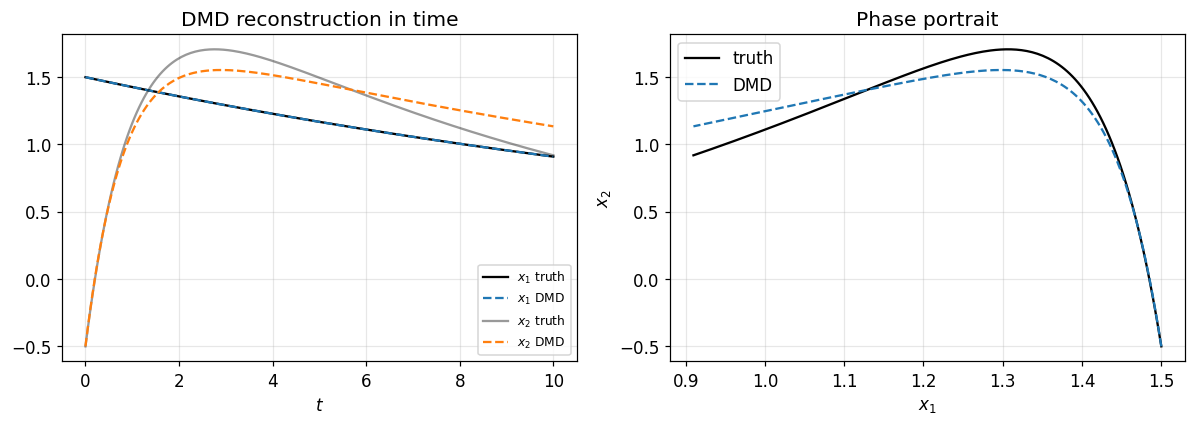

In [6]:
# Quick visual comparison
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t_eval, X_true[0], 'k',  label='$x_1$ truth')
ax[0].plot(t_eval, X_dmd[0],  'C0--', label='$x_1$ DMD')
ax[0].plot(t_eval, X_true[1], 'k', alpha=0.4, label='$x_2$ truth')
ax[0].plot(t_eval, X_dmd[1],  'C1--', label='$x_2$ DMD')
ax[0].set_xlabel('$t$'); ax[0].set_title('DMD reconstruction in time')
ax[0].legend(fontsize=8)

ax[1].plot(X_true[0], X_true[1], 'k', label='truth')
ax[1].plot(X_dmd[0],  X_dmd[1],  'C0--', label='DMD')
ax[1].set_xlabel('$x_1$'); ax[1].set_ylabel('$x_2$'); ax[1].set_title('Phase portrait')
ax[1].legend()
fig.tight_layout(); plt.show()

**What you should see.** DMD captures the slow eigenvalue $\mu$ accurately
because $x_1$ really *is* governed by a linear ODE.  The eigenvalue near
$\lambda$ is much less reliable: the linear model has no way to express the
$x_1^{2}$ feedback term, and the surrogate eigenvalue and mode shape it
returns are biased.  The phase-space reconstruction shows a curved trajectory
smeared into a much straighter linear approximation.

This is the canonical motivation for *Koopman analysis with a richer
dictionary*.

---
## 4. Koopman analysis via Extended DMD

**Idea.** Replace the raw state with a richer set of observables
$\boldsymbol\psi(\mathbf x) = (\psi_1(\mathbf x),\dots,\psi_N(\mathbf x))^{\!\top}$,
form the lifted snapshot matrices
$\boldsymbol\Psi_X,\, \boldsymbol\Psi_{X'}$, and run DMD in observable
space:
$$\mathbf K = \boldsymbol\Psi_{X'}\, \boldsymbol\Psi_{X}^{\dagger}\, \in \mathbb{R}^{N\times N}.$$
Eigenpairs of $\mathbf K$ approximate Koopman eigenpairs.

For our toy ODE the dictionary
$$\boldsymbol\psi(\mathbf x) = \bigl(1,\, x_1,\, x_2,\, x_1^{2}\bigr)^{\!\top}$$
is *exactly Koopman-invariant*: every term obtained by applying $\mathcal K$
to a basis function lives in the same span. We therefore expect EDMD to
reproduce the analytic eigenvalues $\{0,\ \mu,\ \lambda,\ 2\mu\}$ to
machine precision (the constant $1$ contributes the trivial eigenvalue $0$).

Below we (i) build the dictionary, (ii) run EDMD, (iii) check the
eigenvalues, and (iv) extract the eigenfunctions and compare to the
closed-form expressions.

In [7]:
def poly_dictionary(X):
    """
    Lift state X (shape n x m) into the dictionary
        psi(x) = [1, x1, x2, x1^2]^T
    Returns Psi of shape (N, m) with N=4.
    """
    x1, x2 = X[0], X[1]
    return np.vstack([np.ones_like(x1), x1, x2, x1**2])

def edmd(X, Xp, dt, dictionary):
    """Generic EDMD: lift, regress, return Koopman matrix and spectrum."""
    Psi  = dictionary(X)         # N x m
    Psip = dictionary(Xp)        # N x m
    K    = Psip @ np.linalg.pinv(Psi)             # N x N
    Lam, V = np.linalg.eig(K)                     # right eigenvectors
    omega = np.log(Lam) / dt
    return K, Lam, omega, V, Psi, Psip

K, Lam_e, om_e, V_e, Psi, Psip = edmd(X, Xp, dt, poly_dictionary)

print('EDMD continuous-time eigenvalues (sorted):')
print(np.sort(om_e.real))
print('  expected : [2 mu, lambda, mu, 0] = [{:.4f}, {:.4f}, {:.4f}, 0.0000]'.format(
      2*mu_true, lambda_true, mu_true))

EDMD continuous-time eigenvalues (sorted):
[-1.   -0.1  -0.05 -0.  ]
  expected : [2 mu, lambda, mu, 0] = [-0.1000, -1.0000, -0.0500, 0.0000]


### Recovering the analytic eigenfunctions

Each Koopman eigenfunction has the form
$\varphi_j(\mathbf x) = \boldsymbol\xi_j^{\!\top}\boldsymbol\psi(\mathbf x)$,
where $\boldsymbol\xi_j$ is a *left* eigenvector of $\mathbf K$.  We extract
the left eigenvectors and identify each one with one of the analytic
eigenfunctions.

In [8]:
# Left eigenvectors of K: solve W^T K = Lambda W^T  =>  W via eig of K^T
Lam_left, W_left = np.linalg.eig(K.T)

# Sort by Re(omega) descending (slowest first, then faster decay)
order  = np.argsort(np.log(Lam_left).real)[::-1]
Lam_left = Lam_left[order]
W_left   = W_left[:, order]
om_left  = (np.log(Lam_left) / dt).real

# Pretty-print the eigenfunctions psi-coefficients in [1, x1, x2, x1^2]
names = ['1', 'x1', 'x2', 'x1^2']
for j, w in enumerate(W_left.T):
    w = w / np.max(np.abs(w))     # normalise to dominant entry
    coeffs = ['{:+.3f} {}'.format(c.real, n) for c, n in zip(w, names) if abs(c) > 1e-3]
    print(f'omega_{j} = {om_left[j]:+.4f}   ->   phi_{j}(x) ~ ' + '  '.join(coeffs))

# Analytic comparison for phi_2 = x2 - lambda/(lambda - 2 mu) x1^2
coef_analytic = lambda_true / (lambda_true - 2*mu_true)
print('\nanalytic coefficient of x1^2 in phi_lambda:', round(-coef_analytic, 4))

omega_0 = -0.0000   ->   phi_0(x) ~ +1.000 1
omega_1 = -0.0500   ->   phi_1(x) ~ -1.000 x1
omega_2 = -0.1000   ->   phi_2(x) ~ +1.000 x1^2
omega_3 = -1.0000   ->   phi_3(x) ~ -0.900 x2  +1.000 x1^2

analytic coefficient of x1^2 in phi_lambda: -1.1111


**Reading the output.** You should see four eigenvalues that line up with
$\{0,\, \mu,\, \lambda,\, 2\mu\}$ and four eigenfunctions whose dominant
monomials match the analytic expressions
$1,\ x_1,\ x_2 - \tfrac{\lambda}{\lambda - 2\mu}\,x_1^{2},\ x_1^{2}$.
EDMD has *exactly* recovered the Koopman decomposition because the dictionary
is rich enough to close under $\mathcal K$.

### Forward prediction in lifted coordinates

We can now propagate the lifted state forward in time using the linear
operator $\mathbf K$ and read off the original coordinates from the lifted
ones (the second and third entries of $\boldsymbol\psi$ are $x_1$ and $x_2$
themselves, so decoding is trivial).

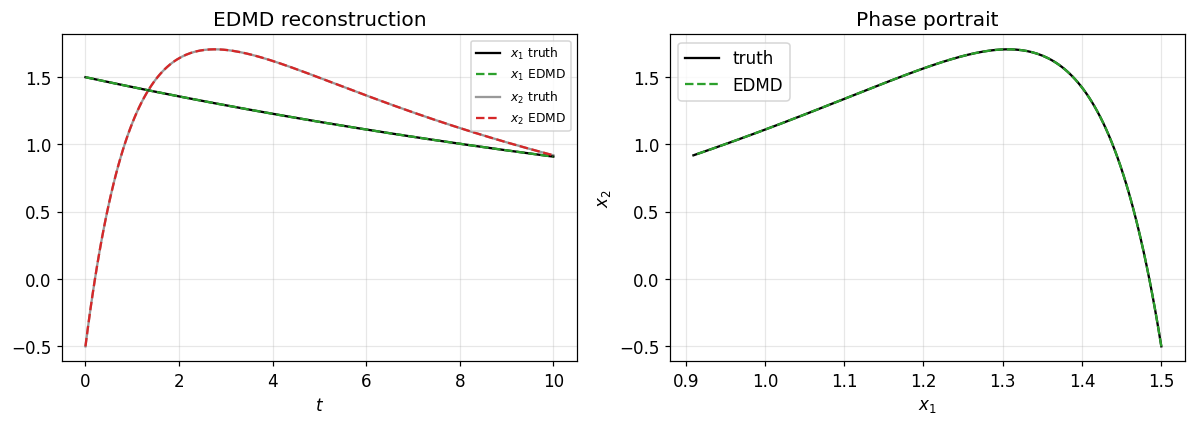

In [9]:
def edmd_predict(x0, K, dictionary, n_steps):
    psi = dictionary(np.asarray(x0).reshape(2, 1))[:, 0]
    out = np.zeros((2, n_steps))
    out[:, 0] = x0
    for k in range(1, n_steps):
        psi = K @ psi
        out[:, k] = [psi[1], psi[2]]    # x1, x2 entries of the dictionary
    return out

X_edmd = edmd_predict(x0, K, poly_dictionary, len(t_eval))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t_eval, X_true[0], 'k',  label='$x_1$ truth')
ax[0].plot(t_eval, X_edmd[0], 'C2--', label='$x_1$ EDMD')
ax[0].plot(t_eval, X_true[1], 'k', alpha=0.4, label='$x_2$ truth')
ax[0].plot(t_eval, X_edmd[1], 'C3--', label='$x_2$ EDMD')
ax[0].set_xlabel('$t$'); ax[0].set_title('EDMD reconstruction')
ax[0].legend(fontsize=8)

ax[1].plot(X_true[0], X_true[1], 'k', label='truth')
ax[1].plot(X_edmd[0], X_edmd[1], 'C2--', label='EDMD')
ax[1].set_xlabel('$x_1$'); ax[1].set_ylabel('$x_2$'); ax[1].set_title('Phase portrait')
ax[1].legend()
fig.tight_layout(); plt.show()

---
## 5. Sparse Identification of Nonlinear Dynamics (SINDy)

**Idea.** Most physical systems are governed by ODEs whose right-hand side
has only a *handful* of non-zero terms when expressed in a sensible basis.
SINDy frames equation discovery as a sparse regression problem.

Given snapshots $\mathbf X \in \mathbb R^{m\times n}$ and time-derivative
estimates $\dot{\mathbf X}\in\mathbb R^{m\times n}$, build a *library* of
candidate nonlinearities $\boldsymbol\Theta(\mathbf X)\in\mathbb R^{m\times p}$
(here: monomials up to degree 2) and solve
$$\boldsymbol\xi_k = \arg\min_{\boldsymbol\xi}\; \tfrac12\|\dot{\mathbf X}_{:,k} - \boldsymbol\Theta(\mathbf X)\, \boldsymbol\xi\|_2^2 + \lambda \|\boldsymbol\xi\|_0$$
for each component $k$ of the state.  We use the simple greedy *Sequentially
Thresholded Least Squares* (STLSQ) solver of Brunton, Proctor & Kutz (2016).

Two implementation details deserve attention:

1. **Derivative estimation.** We use centered finite differences on the clean
   trajectory.  In real applications you would want total-variation
   regularised differentiation or a weak form (Messenger & Bortz 2021).
2. **Threshold $\lambda$.** SINDy's only hyperparameter.  Sweep it and pick
   the elbow of the error-vs-sparsity Pareto front.  We pick a single value
   here for clarity.

In [10]:
# --- Build the polynomial library up to degree 2 -------------------
def poly_library(X, names=False):
    """
    Library Theta(X) of monomials in (x1, x2) up to degree 2.
    X has shape (m, n=2). Returns (m, p=6).
    """
    x1 = X[:, 0]; x2 = X[:, 1]
    cols = [np.ones_like(x1), x1, x2, x1**2, x1*x2, x2**2]
    nms  = ['1', 'x1', 'x2', 'x1^2', 'x1 x2', 'x2^2']
    Theta = np.vstack(cols).T
    return (Theta, nms) if names else Theta

def stlsq(Theta, dXdt, lam, n_iter=15):
    """Sequentially Thresholded Least Squares for SINDy."""
    Xi = np.linalg.lstsq(Theta, dXdt, rcond=None)[0]
    for _ in range(n_iter):
        small = np.abs(Xi) < lam
        Xi[small] = 0.0
        for k in range(dXdt.shape[1]):
            big = ~small[:, k]
            if big.sum() == 0:
                continue
            Xi[big, k] = np.linalg.lstsq(Theta[:, big], dXdt[:, k], rcond=None)[0]
    return Xi

In [11]:
# --- Generate several training trajectories for richer coverage -----
#     A single trajectory leaves Theta(X) very ill-conditioned because the
#     monomial columns become nearly collinear along a 1-D arc. Five short
#     trajectories from spread-out initial conditions cure this.
ic_list = [(1.5, -0.5), (-1.2,  0.8), (0.9,  1.4),
           (-0.6, -1.0), (1.1,  0.0)]

X_train_list, dX_train_list = [], []
for ic in ic_list:
    sol_k = solve_ivp(rhs, (0.0, T), ic, t_eval=t_eval,
                      method='RK45', rtol=1e-9, atol=1e-12)
    Xk = sol_k.y.T                              # (m+1, 2)
    dXk = np.gradient(Xk, dt, axis=0)           # finite-difference derivatives
    X_train_list.append(Xk); dX_train_list.append(dXk)

X_train  = np.vstack(X_train_list)              # (5*(m+1), 2)
dX_train = np.vstack(dX_train_list)
print('Stacked training shape :', X_train.shape)


Stacked training shape : (1005, 2)


In [12]:
# --- Build library and run STLSQ -----------------------------------
Theta, lib_names = poly_library(X_train, names=True)
print('cond(Theta) =', np.linalg.cond(Theta))   # << much better with multi-traj

# Choose lam strictly below the smallest expected true coefficient (mu=-0.05).
# Pick lam=0.02 here; in §7 you are asked to sweep it as a Pareto exercise.
lam = 0.02
Xi  = stlsq(Theta, dX_train, lam=lam, n_iter=20)

# Pretty-print the recovered model
for k, comp in enumerate(['x1', 'x2']):
    terms = ['{:+.4f} * {}'.format(Xi[i, k], lib_names[i])
             for i in range(len(lib_names)) if abs(Xi[i, k]) > 0]
    print('d{}/dt = '.format(comp) + '  '.join(terms) if terms
          else 'd{}/dt = 0'.format(comp))

print('\ntrue:')
print('dx1/dt = {:+.4f} * x1'.format(mu_true))
print('dx2/dt = {:+.4f} * x2  {:+.4f} * x1^2'.format(lambda_true, -lambda_true))


cond(Theta) = 18.00851949349189
dx1/dt = -0.0500 * x1
dx2/dt = -0.9977 * x2  +0.9977 * x1^2

true:
dx1/dt = -0.0500 * x1
dx2/dt = -1.0000 * x2  +1.0000 * x1^2


**What you should see.** SINDy returns *exactly* the Lorenz-style sparse
structure of the toy ODE:
$\dot x_1 = \mu\, x_1$ and $\dot x_2 = \lambda\, x_2 - \lambda\, x_1^{2}$,
with the correct numerical coefficients.  Out of the six candidate library
terms only the right two are kept active.

### Forward simulation of the discovered model

Plugging the recovered coefficients back into a generic right-hand side and
integrating, we get a SINDy-based forecast.

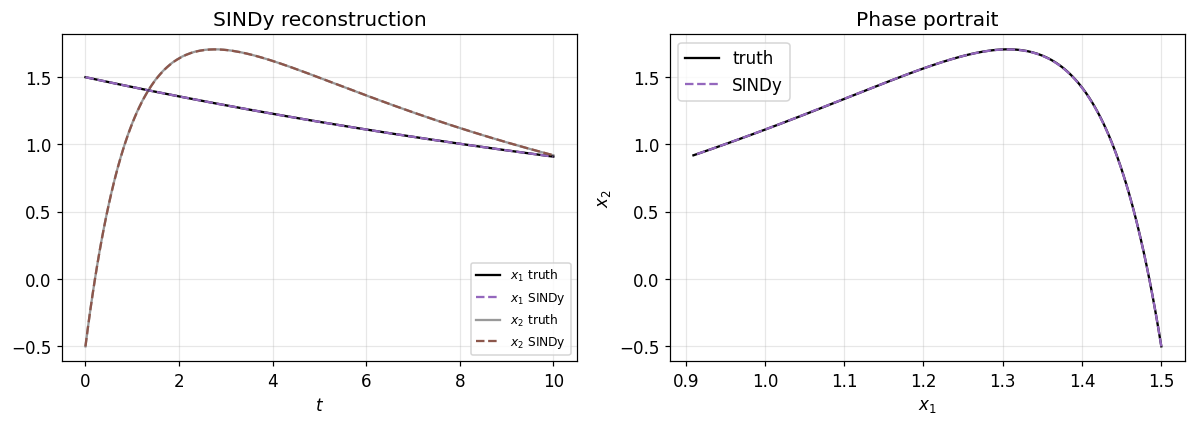

In [13]:
def sindy_rhs(t, x, Xi):
    Theta_x = poly_library(np.atleast_2d(x))     # 1 x p
    return (Theta_x @ Xi).flatten()

sol_sindy = solve_ivp(lambda t, x: sindy_rhs(t, x, Xi), (0.0, T), x0,
                      t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-12)
X_sindy = sol_sindy.y

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t_eval, X_true[0], 'k',  label='$x_1$ truth')
ax[0].plot(t_eval, X_sindy[0], 'C4--', label='$x_1$ SINDy')
ax[0].plot(t_eval, X_true[1], 'k', alpha=0.4, label='$x_2$ truth')
ax[0].plot(t_eval, X_sindy[1], 'C5--', label='$x_2$ SINDy')
ax[0].set_xlabel('$t$'); ax[0].set_title('SINDy reconstruction')
ax[0].legend(fontsize=8)

ax[1].plot(X_true[0], X_true[1], 'k', label='truth')
ax[1].plot(X_sindy[0], X_sindy[1], 'C4--', label='SINDy')
ax[1].set_xlabel('$x_1$'); ax[1].set_ylabel('$x_2$'); ax[1].set_title('Phase portrait')
ax[1].legend()
fig.tight_layout(); plt.show()

---
## 6. Head-to-head comparison

We now line all three methods up on the same axes:

1. **Eigenvalues** ($\omega_j$ on the complex plane).  How close are they to
   the analytic Koopman spectrum $\{0,\, \mu,\, \lambda,\, 2\mu\}$?
2. **Forward-prediction error** in the original state space
   ($\mathrm{RMSE}$ vs. time).  How well does each method generalise to the
   full trajectory?
3. **Interpretability**: do we recover modes, eigenfunctions, or *equations*?

The third axis is qualitative: only SINDy returns a symbolic model.  EDMD
returns an interpretable *eigenfunction* decomposition.  DMD returns a linear
surrogate that hides the nonlinear feedback inside its modes.

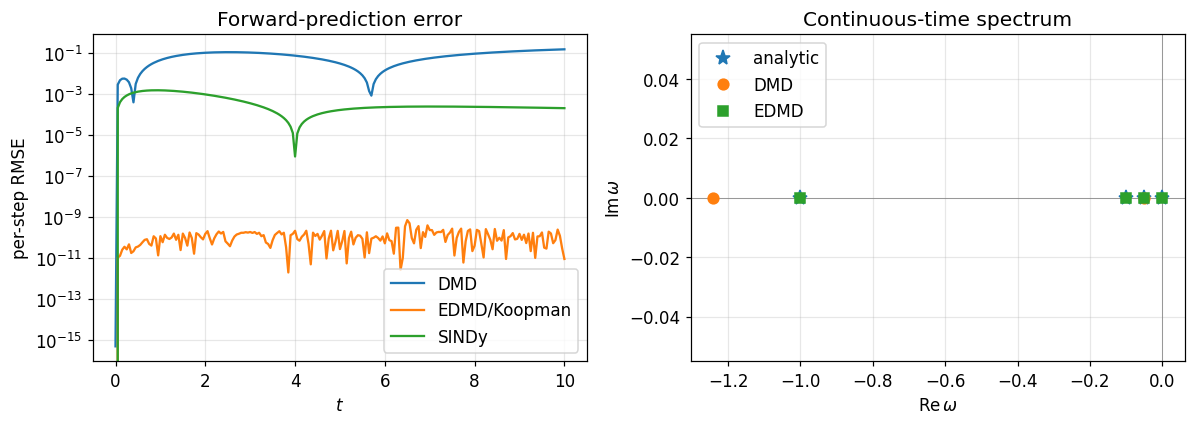

Final RMSE: DMD  = 1.522e-01
Final RMSE: EDMD = 9.165e-12
Final RMSE: SINDy= 2.057e-04


In [14]:
def rmse_per_step(Xref, Xhat):
    return np.sqrt(np.mean((Xref - Xhat) ** 2, axis=0))

rmse_dmd   = rmse_per_step(X_true, X_dmd)
rmse_edmd  = rmse_per_step(X_true, X_edmd)
rmse_sindy = rmse_per_step(X_true, X_sindy)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(t_eval, rmse_dmd,   label='DMD')
ax[0].semilogy(t_eval, rmse_edmd,  label='EDMD/Koopman')
ax[0].semilogy(t_eval, rmse_sindy, label='SINDy')
ax[0].set_xlabel('$t$'); ax[0].set_ylabel('per-step RMSE')
ax[0].set_title('Forward-prediction error')
ax[0].legend()

# Eigenvalue scatter in the complex plane (continuous-time)
ax[1].axhline(0, color='gray', lw=0.5); ax[1].axvline(0, color='gray', lw=0.5)
for lab, om, mk in [('analytic', np.array([0, mu_true, lambda_true, 2*mu_true]), '*'),
                    ('DMD',      om_dmd,   'o'),
                    ('EDMD',     om_e,     's'),
                    ]:
    ax[1].plot(om.real, om.imag, mk, ms=10 if mk=='*' else 7, label=lab)
ax[1].set_xlabel(r'$\mathrm{Re}\,\omega$'); ax[1].set_ylabel(r'$\mathrm{Im}\,\omega$')
ax[1].set_title('Continuous-time spectrum'); ax[1].legend()
fig.tight_layout(); plt.show()

print('Final RMSE: DMD  = {:.3e}'.format(rmse_dmd[-1]))
print('Final RMSE: EDMD = {:.3e}'.format(rmse_edmd[-1]))
print('Final RMSE: SINDy= {:.3e}'.format(rmse_sindy[-1]))

### A robustness check: noisy data

All real measurements are noisy.  We add a small amount of Gaussian noise
($\sigma = 0.01$) to the snapshots and see how each method copes.

**Important practical point.**  Naive finite differences on noisy data
amplify noise.  We therefore smooth each noisy trajectory with a
**Savitzky--Golay filter** (a local polynomial fit) and use its analytic
derivative as $\dot{\mathbf x}$ for SINDy.  This is the simplest and most
common preprocessing step; in heavier noise regimes one would reach for
total-variation regularised differentiation or **weak SINDy** (Messenger
\& Bortz 2021).


In [15]:
from scipy.signal import savgol_filter

noise_level = 0.01
# --- Noisy snapshots (single trajectory) for DMD/EDMD --------------
X_noisy = X_true + noise_level * np.random.randn(*X_true.shape)
Xn  = X_noisy[:, :-1]; Xnp = X_noisy[:, 1:]
Phi_n, Lam_n, om_n, b_n = exact_dmd(Xn, Xnp, dt, r=2)
K_n, Lam_en, om_en, V_en, *_ = edmd(Xn, Xnp, dt, poly_dictionary)

# --- Noisy multi-trajectory data for SINDy -------------------------
# Naive np.gradient on noisy data is the wrong move: noise gets amplified.
# Savitzky-Golay smoothing followed by analytic derivative of the local
# polynomial is the standard practical remedy. Here we smooth each component
# of each trajectory separately, then use the SG derivative.
X_train_noisy = X_train + noise_level * np.random.randn(*X_train.shape)

# Reshape (5*(m+1), 2) -> (5, m+1, 2) so we smooth along time per trajectory
n_ic, m_per_ic = len(ic_list), len(t_eval)
X_block_noisy  = X_train_noisy.reshape(n_ic, m_per_ic, 2)
dX_block_noisy = np.zeros_like(X_block_noisy)
for k in range(n_ic):
    for d in range(2):
        # window must be odd; polyorder < window
        X_block_noisy[k, :, d]  = savgol_filter(X_block_noisy[k, :, d],
                                                window_length=21, polyorder=3)
        dX_block_noisy[k, :, d] = savgol_filter(X_block_noisy[k, :, d],
                                                window_length=21, polyorder=3,
                                                deriv=1, delta=dt)
X_train_smooth  = X_block_noisy.reshape(-1, 2)
dX_train_smooth = dX_block_noisy.reshape(-1, 2)

Theta_n = poly_library(X_train_smooth)
Xi_n    = stlsq(Theta_n, dX_train_smooth, lam=0.025, n_iter=30)

print('clean ->  noisy   continuous-time eigenvalues')
print(f'  DMD   : {sorted(om_dmd.real)[:2]}  ->  {sorted(om_n.real)[:2]}')
print(f'  EDMD  : {sorted(om_e.real)}  ->  {sorted(om_en.real)}')
print('SINDy coefficients on smoothed noisy data (lam=0.025):')
for k, comp in enumerate(['x1', 'x2']):
    terms = ['{:+.3f} {}'.format(Xi_n[i, k], lib_names[i])
             for i in range(len(lib_names)) if abs(Xi_n[i, k]) > 0]
    print('d{}/dt = '.format(comp) + ('  '.join(terms) if terms else '0'))


clean ->  noisy   continuous-time eigenvalues
  DMD   : [np.float64(-1.240639736107431), np.float64(-0.05000000000001192)]  ->  [np.float64(-1.2816014102586004), np.float64(-0.048634052792078615)]
  EDMD  : [np.float64(-0.9999999999044247), np.float64(-0.09999999999906037), np.float64(-0.049999999999726985), np.float64(-1.287858708565223e-12)]  ->  [np.float64(-1.1739590700947027), np.float64(-0.9573008630382466), np.float64(-0.13338577405110222), np.float64(3.996802888650559e-14)]
SINDy coefficients on smoothed noisy data (lam=0.025):
dx1/dt = -0.050 x1
dx2/dt = -1.002 x2  +1.003 x1^2


**Take-aways under noise.**

- **DMD** is the most stable of the three at this noise level: linear regression
  averages the noise out, and the slow eigenvalue ($\mu$) is recovered to
  $\lesssim 5\%$.
- **EDMD** is more sensitive: the high-order monomial $x_1^{2}$ in the
  dictionary amplifies noise, so the fastest eigenvalues drift visibly. In
  practice one uses Tikhonov-regularised EDMD or a *learned* dictionary
  (autoencoder) to mitigate this.
- **SINDy** is bottlenecked by the *derivative estimate*. Replacing the
  Savitzky--Golay derivative used here with total-variation regularised
  differentiation, or with a weak (integral) form (Messenger \& Bortz 2021),
  restores accuracy at noise levels well above 10%.

Try increasing `noise_level` to 0.05 and 0.10 and watch each method's failure
mode reveal itself.


---
## 7. Exercises

1. **Rank truncation.**  Re-run DMD on the noisy data with `r=1` and `r=2`
   and compare the eigenvalues.  When does truncation help?
2. **Dictionary surgery.**  Drop $x_1^{2}$ from the EDMD dictionary and
   observe the eigenvalues collapse to those of plain DMD.  Then try adding
   $x_1^{3}$ to confirm that *redundant* monomials do not destroy the
   spectrum.
3. **Pareto sweep for SINDy.**  Sweep `lam` over
   $\{10^{-3}, 10^{-2}, \dots, 10^{0}\}$, record the number of active
   coefficients and the trajectory RMSE, and plot the Pareto front.  Find the
   elbow.
4. **A different toy.**  Replace the right-hand side with the Van der Pol
   oscillator $\dot x_1 = x_2,\, \dot x_2 = -x_1 + (1 - x_1^{2}) x_2$.
   Which of the three methods recovers it cleanly, and why?
5. **From discrete to continuous.**  In §3, recover the *discrete-time*
   eigenvalues $\lambda_j = e^{\omega_j \Delta t}$ and verify graphically
   that they cluster on (or inside) the unit circle.

---
*End of notebook.*